# Clasificación Básica: Predecir una imagen de moda

Esta Guia entrena un modelo de red neuronal para clasificar imágenes de ropa, como tennis y camisetas.

Esta Guia usa [tf.keras](https://www.tensorflow.org/guide/keras), un API de alto nivel para construir y entrenar modelos en Tensorflow.

## Importar el set de datos de moda de MNIST

Esta guia usa el set de datos de [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist)
que contiene mas de 70,000 imágenes en 10 categorias. Las imágenes muestran articulos individuales de ropa a una resolucion baja (28 por 28 pixeles) como se ve aca:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Para importar y cargar el set de datos de MNIST directamente de TensorFlow:

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow import keras

In [22]:
# keras.datasets.fashion_mnist


In [23]:
dataset = keras.datasets.fashion_mnist
dataset.load_data()

((array([[[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         ...,
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          ...,
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0]],
  
         [[0, 0, 0, ..., 0, 0, 0],
          [0, 0, 0, ..., 0, 0, 0

In [24]:
len(dataset.load_data()[0]) # Cada imagen tiene 2 dimensiones

2

In [25]:
(X_train, y_train), (X_test, y_test) = dataset.load_data()

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(60000, 28, 28)
(10000, 28, 28)
(60000,)
(10000,)


La *class* de ropa que la imagen representa.

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Cada imagen es mapeada a una unica etiqueta. Ya que los *Class names* no estan incluidos en el dataset. Los guardamos en la siguiente lista:

In [26]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
len(class_names)

10

In [27]:
y_train

array([9, 0, 0, ..., 3, 0, 5], shape=(60000,), dtype=uint8)

## Explore el set de datos

* ¿Cuántas imágenes hay en train?
* ¿Y en test?
* ¿De cuántos pixels se compone cada imagen?
* ¿Cuáles son los valores de los labels?

In [28]:
# 1. ¿Cuántas imágenes hay en train?
X_train.shape[0]

60000

In [29]:
# 2. ¿Cuántas imágenes hay en test?
X_test.shape[0]

10000

In [30]:
# 3. ¿De cuántos pixels se compone cada imagen?
X_train.shape[1] * X_train.shape[2]

784

In [31]:
# ¿Cuáles son los valores de los labels?
print('\nLABELS')
for label in np.unique(y_train):
    print(label, '-', class_names[label])


LABELS
0 - T-shirt/top
1 - Trouser
2 - Pullover
3 - Dress
4 - Coat
5 - Sandal
6 - Shirt
7 - Sneaker
8 - Bag
9 - Ankle boot


## Pre-procese el set de datos

Inspecciona y representa la primera imagen del dataset de train. Para ello, utiliza la función `imshow` de matplotlib.

In [32]:
# Primera imagen del train
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  

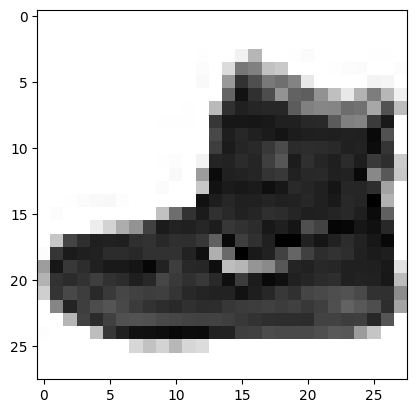

In [33]:
# Representar la primera imagen del train con imshow
plt.imshow(X_train[0], cmap="binary");

Escala los conjuntos de train y test para que vayan del 0 al 1. No hace falta usar ninguna librería. Con realizar una división en cada conjunto será suficiente.

In [34]:
X_train.min()

np.uint8(0)

In [35]:
X_train.max()

np.uint8(255)

In [36]:
# Se divide en 255 que es el max
X_train = X_train/255
X_test = X_test/255

In [37]:
# Comprobar que está bien realizado
X_train.min()

np.float64(0.0)

In [38]:
# Comprobar que está bien realizado
X_train.max()

np.float64(1.0)

Para verificar que el set de datos está en el formato adecuado y que están listos para construir y entrenar la red, vamos a desplegar las primeras 25 imágenes del *training set* y despleguemos el nombre de cada clase debajo de cada imagen.

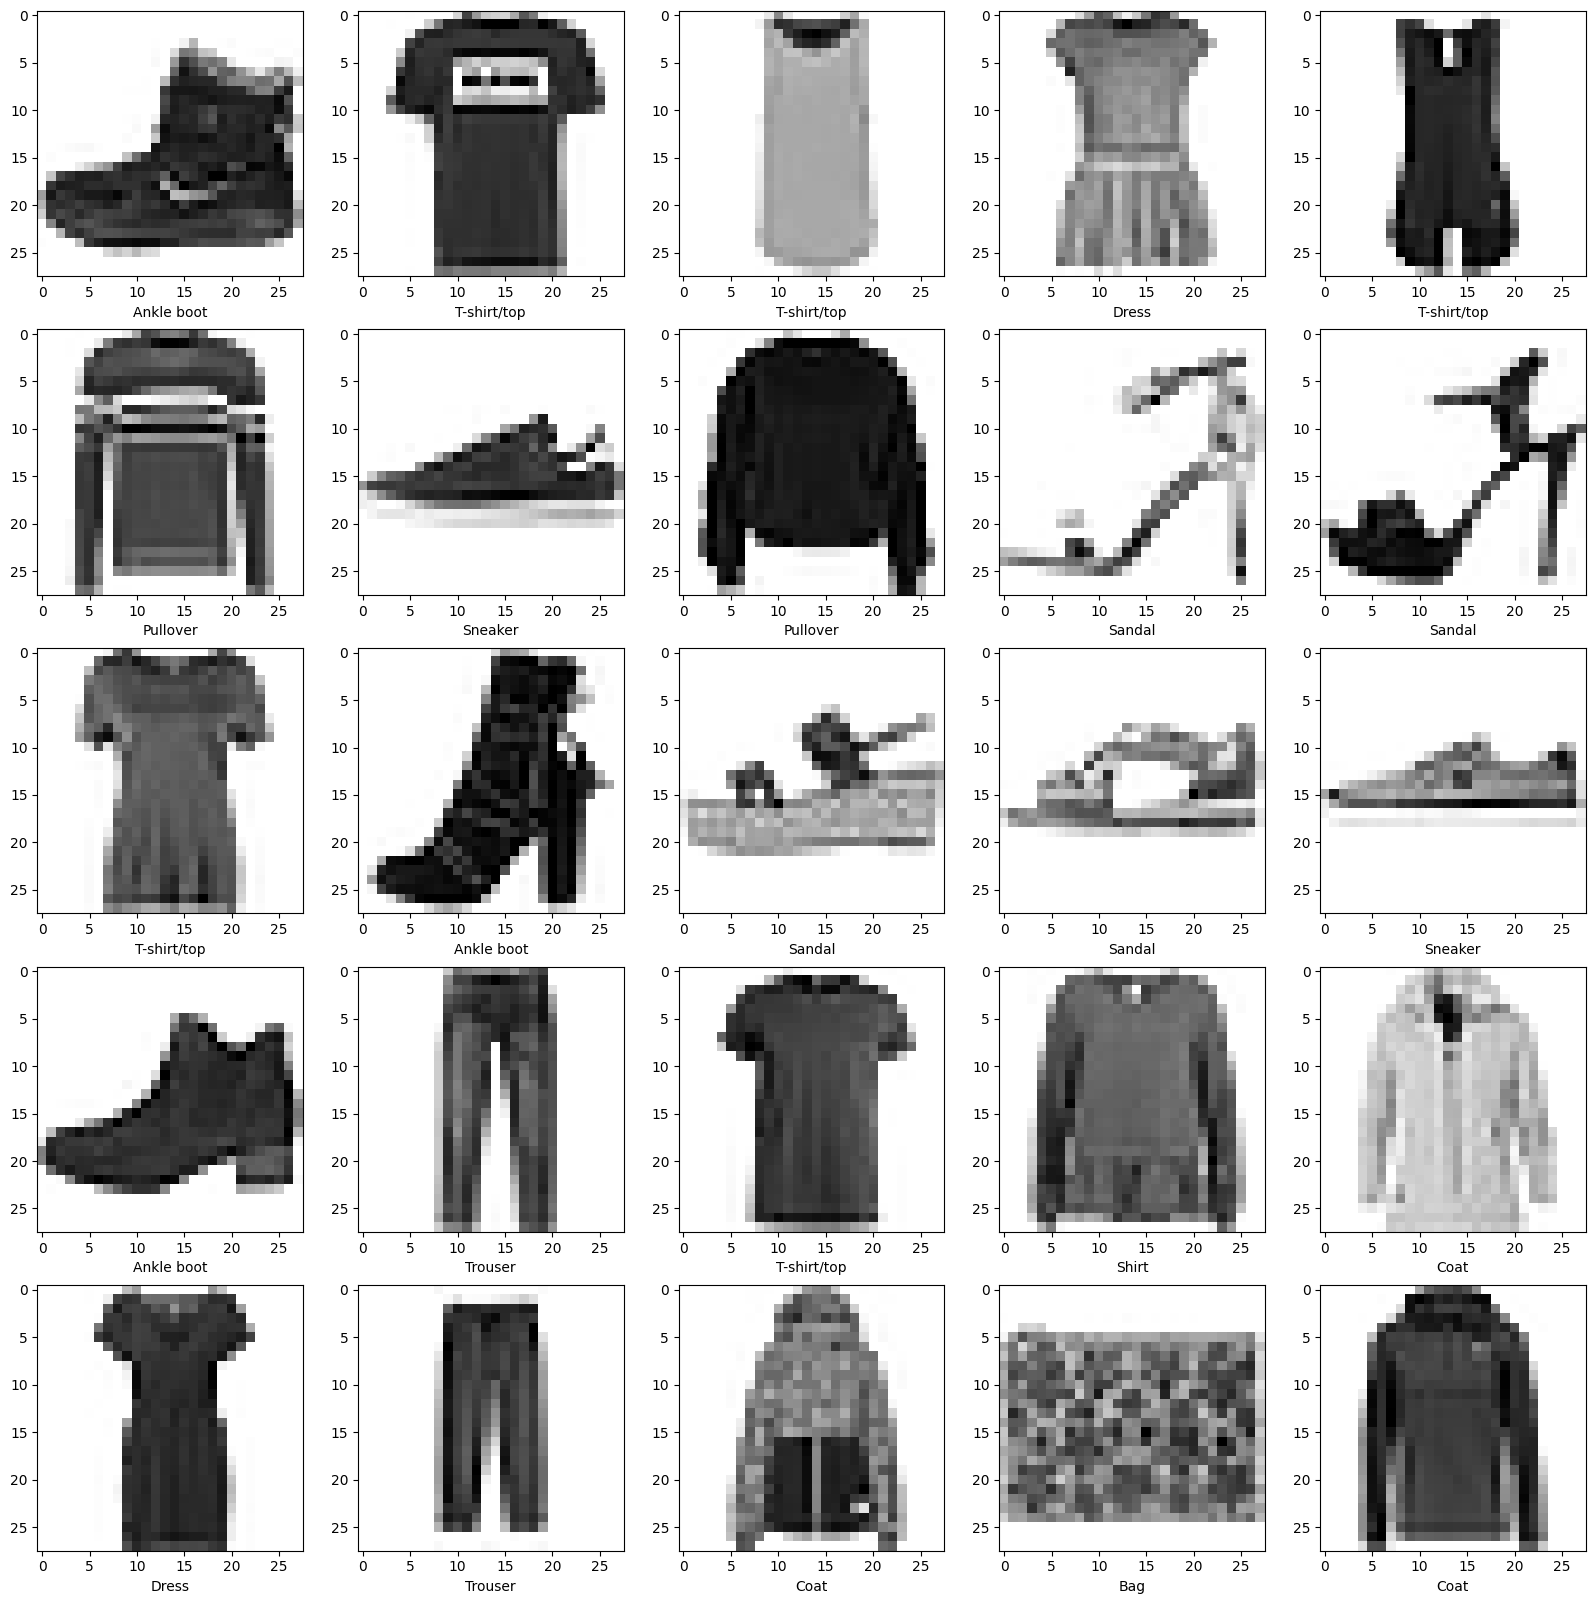

In [39]:
plt.figure(figsize=(20,20))
for i in range(25):
    plt.subplot(5,5, i+1)
    plt.imshow(X_train[i], cmap="binary")
    plt.xlabel(class_names[y_train[i]]);

## Construir el Modelo

Construir la red neuronal requiere configurar las capas del modelo y luego compilar el modelo.

### Configurar las Capas
Construye todas las capas del modelo.

In [47]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)), # Capa de entrada: aplana 28x28 → 784
    keras.layers.Dense(256,activation="relu"), # Capa oculta
    keras.layers.Dense(10, activation="softmax") # Capa de salida: 10 clases
])

/Users/fgoiri/miniconda3/envs/bootcamp2/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Compila el modelo

Antes de que el modelo este listo para entrenar , se necesitan algunas configuraciones más. Estas son agregadas durante el paso de compilacion del modelo:

* *Loss function* —Esto mide que tan exacto es el modelo durante el entrenamiento. Quiere minimizar esta función para dirigir el modelo en la dirección adecuada.
* *Optimizer* — Esto es cómo el modelo aprende basado en el set de datos que ve y la función de pérdida.
* *Metrics* — Se usan para monitorear los pasos de entrenamiento y de pruebas.


Como es un problema de clasificación multiclase, tendrás que usar `sparse_categorical_crossentropy` como función de coste. En cuanto a las métricas, usa simplemente `accuracy`.

In [48]:
model.compile(optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [49]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,530 (795.04 KB)

 Trainable params: 203,530 (795.04 KB)

 Non-trainable params: 0 (0.00 B)

## Entrenar el Modelo
Empieza entrenándolo con 10 epochs. Prueba con más

In [50]:
history = model.fit(X_train, y_train, epochs=10, validation_split=0.1)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8249 - loss: 0.4928 - val_accuracy: 0.8637 - val_loss: 0.3755
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8658 - loss: 0.3701 - val_accuracy: 0.8680 - val_loss: 0.3592
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8777 - loss: 0.3308 - val_accuracy: 0.8533 - val_loss: 0.3906
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 932us/step - accuracy: 0.8877 - loss: 0.3046 - val_accuracy: 0.8828 - val_loss: 0.3249
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 959us/step - accuracy: 0.8918 - loss: 0.2880 - val_accuracy: 0.8860 - val_loss: 0.3267
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 923us/step - accuracy: 0.8996 - loss: 0.2703 - val_accuracy: 0.8818 - val_loss: 0.3256
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 926us/step - accuracy: 0.9049 - loss: 0.2587 - val_accuracy: 0.8852 - val_loss: 0.3135
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 2s 924us/step - accuracy: 0.9079 - loss:

<Axes: >

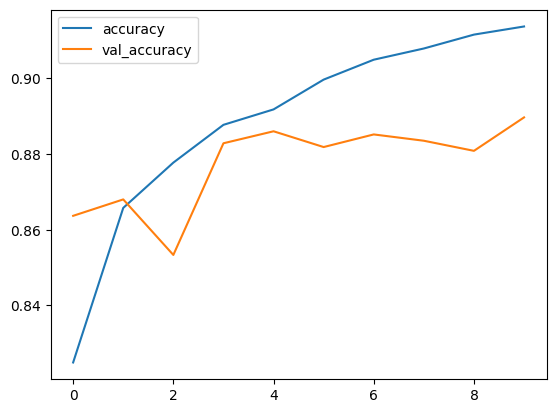

In [51]:
pd.DataFrame(history.history)[['accuracy', 'val_accuracy']].plot()

In [52]:
results = model.evaluate(X_test, y_test, verbose=2)
print(f'\nTest accuracy: {results[1]:.4f}')

313/313 - 0s - 383us/step - accuracy: 0.8858 - loss: 0.3368

Test accuracy: 0.8858


In [53]:
# Le meto una capa más
model_2 = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(256,activation="relu"),
    keras.layers.Dense(256,activation="relu"),
    keras.layers.Dense(10, activation="softmax")
])

model_2.compile(optimizer="sgd",
              loss = "sparse_categorical_crossentropy",
              metrics = ['accuracy'])


/Users/fgoiri/miniconda3/envs/bootcamp2/lib/python3.11/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [55]:
# Subimos epochs y le metemos el early stopping para no volvernos locos
history_2 = model_2.fit(X_train, y_train, epochs=30, validation_split=0.1, callbacks=[keras.callbacks.EarlyStopping(patience=5)])

Epoch 1/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 806us/step - accuracy: 0.8777 - loss: 0.3414 - val_accuracy: 0.8720 - val_loss: 0.3597
Epoch 2/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 751us/step - accuracy: 0.8828 - loss: 0.3319 - val_accuracy: 0.8665 - val_loss: 0.3711
Epoch 3/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 797us/step - accuracy: 0.8859 - loss: 0.3232 - val_accuracy: 0.8713 - val_loss: 0.3532
Epoch 4/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 787us/step - accuracy: 0.8869 - loss: 0.3165 - val_accuracy: 0.8783 - val_loss: 0.3395
Epoch 5/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 789us/step - accuracy: 0.8892 - loss: 0.3087 - val_accuracy: 0.8802 - val_loss: 0.3381
Epoch 6/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 785us/step - accuracy: 0.8918 - loss: 0.3016 - val_accuracy: 0.8703 - val_loss: 0.3617
Epoch 7/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 833us/step - accuracy: 0.8938 - loss: 0.2954 - val_accuracy: 0.8740 - val_loss: 0.3462
Epoch 8/30
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 1s 755us/step - accuracy: 0.8951 -

<Axes: >

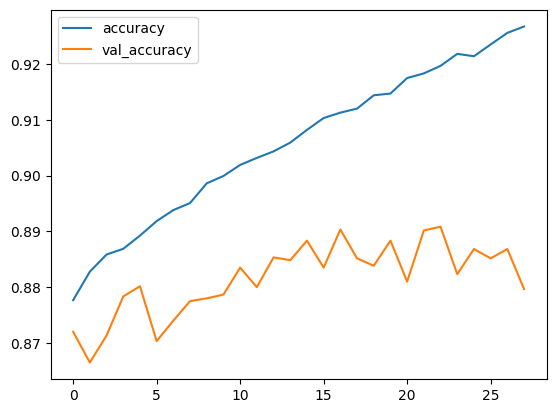

In [ ]:
# QUÉ HORRORRRR!!
pd.DataFrame(history_2.history)[['accuracy', 'val_accuracy']].plot()

## Evaluar Accuracy
Prueba el rendimiento del modelo con los datos de test

In [ ]:
# Evaluación modelo 1
model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 393us/step - accuracy: 0.8858 - loss: 0.3368


[0.3368273377418518, 0.8858000040054321]

In [ ]:
# Evaluación modelo 2
model_2.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 474us/step - accuracy: 0.8718 - loss: 0.3742


[0.3742307424545288, 0.8718000054359436]

## Hacer predicciones

Con el modelo entrenado puedes usarlo para hacer predicciones sobre imagenes.

In [59]:
y_pred = model.predict(X_test)
y_pred

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 360us/step


array([[2.62157016e-07, 4.60464167e-11, 2.64943711e-08, ...,
        2.94625349e-02, 9.50965348e-11, 9.70338821e-01],
       [1.32035975e-05, 2.16216891e-15, 9.99867797e-01, ...,
        5.28027601e-18, 9.20524837e-11, 1.85075598e-15],
       [2.51221214e-11, 1.00000000e+00, 1.59068489e-15, ...,
        8.50793095e-30, 1.48449737e-16, 9.15378812e-24],
       ...,
       [2.18509354e-06, 2.53017572e-12, 4.35165894e-05, ...,
        8.89747789e-11, 9.99801278e-01, 1.98109584e-12],
       [5.40227141e-10, 9.99999642e-01, 5.22063512e-13, ...,
        2.80482077e-18, 1.64597079e-12, 2.77230644e-15],
       [2.60644856e-06, 1.84309212e-09, 4.86171939e-06, ...,
        7.31230190e-04, 2.88996080e-06, 1.06467917e-06]],
      shape=(10000, 10), dtype=float32)

In [60]:
y_pred_labels = np.argmax(y_pred, axis=1)
y_pred_labels

array([9, 2, 1, ..., 8, 1, 5], shape=(10000,))

El modelo ha predicho la etiqueta para cada imagen en el set de datos de *test* (prueba). Miremos la primera prediccion:

In [61]:
y_pred[0]

array([2.6215702e-07, 4.6046417e-11, 2.6494371e-08, 5.0124152e-13,
       2.7808249e-09, 1.9837203e-04, 1.5919220e-08, 2.9462535e-02,
       9.5096535e-11, 9.7033882e-01], dtype=float32)

In [62]:
y_pred_labels[0]

np.int64(9)

In [63]:
class_names[y_pred_labels[0]]

'Ankle boot'

*Una* prediccion es un array de 10 numeros. Estos representan el nivel de "confianza" del modelo sobre las imagenes de cada uno de los 10 articulos de moda/ropa. Puedes revisar cual tiene el nivel mas alto de confianza:

In [64]:
def plot_image(i, predictions_array, true_label, img):
  predictions_array, true_label, img = predictions_array, true_label[i], img[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img, cmap=plt.cm.binary)

  predicted_label = np.argmax(predictions_array)
  if predicted_label == true_label:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

def plot_value_array(i, predictions_array, true_label):
  predictions_array, true_label = predictions_array, true_label[i]
  plt.grid(False)
  plt.xticks(range(10))
  plt.yticks([])
  thisplot = plt.bar(range(10), predictions_array, color="#777777")
  plt.ylim([0, 1])
  predicted_label = np.argmax(predictions_array)

  thisplot[predicted_label].set_color('red')
  thisplot[true_label].set_color('blue')

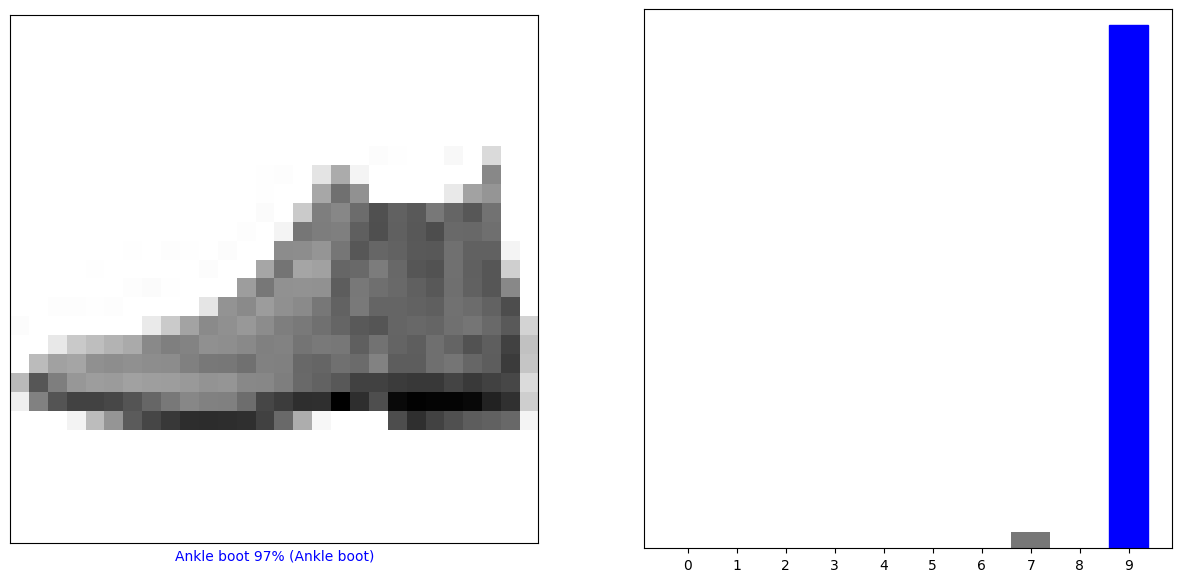

In [65]:
i = 0
plt.figure(figsize=(15,7))
plt.subplot(1,2,1)
plot_image(i, y_pred[i], y_test, X_test)
plt.subplot(1,2,2)
plot_value_array(i, y_pred[i], y_test)

Entonces, el modelo tiene mayor confianza que esta imagen es un bota de tobillo "ankle boot" o `class_names[9]`. Examinando las etiquetas de *test* o de pruebas muestra que esta clasificación es correcta:

**Grafica** esto para poder ver todo el set de la prediccion de las 10 clases.

Miremos la imagen [0], sus predicciones y el array de predicciones. Las etiquetas de predicción correctas estan en azul y las incorrectas están en rojo. El número entrega el porcentaje (sobre 100) para la etiqueta predicha.

Vamos a graficar multiples imagenes con sus predicciones. Notese que el modelo puede estar equivocado aun cuando tiene mucha confianza.

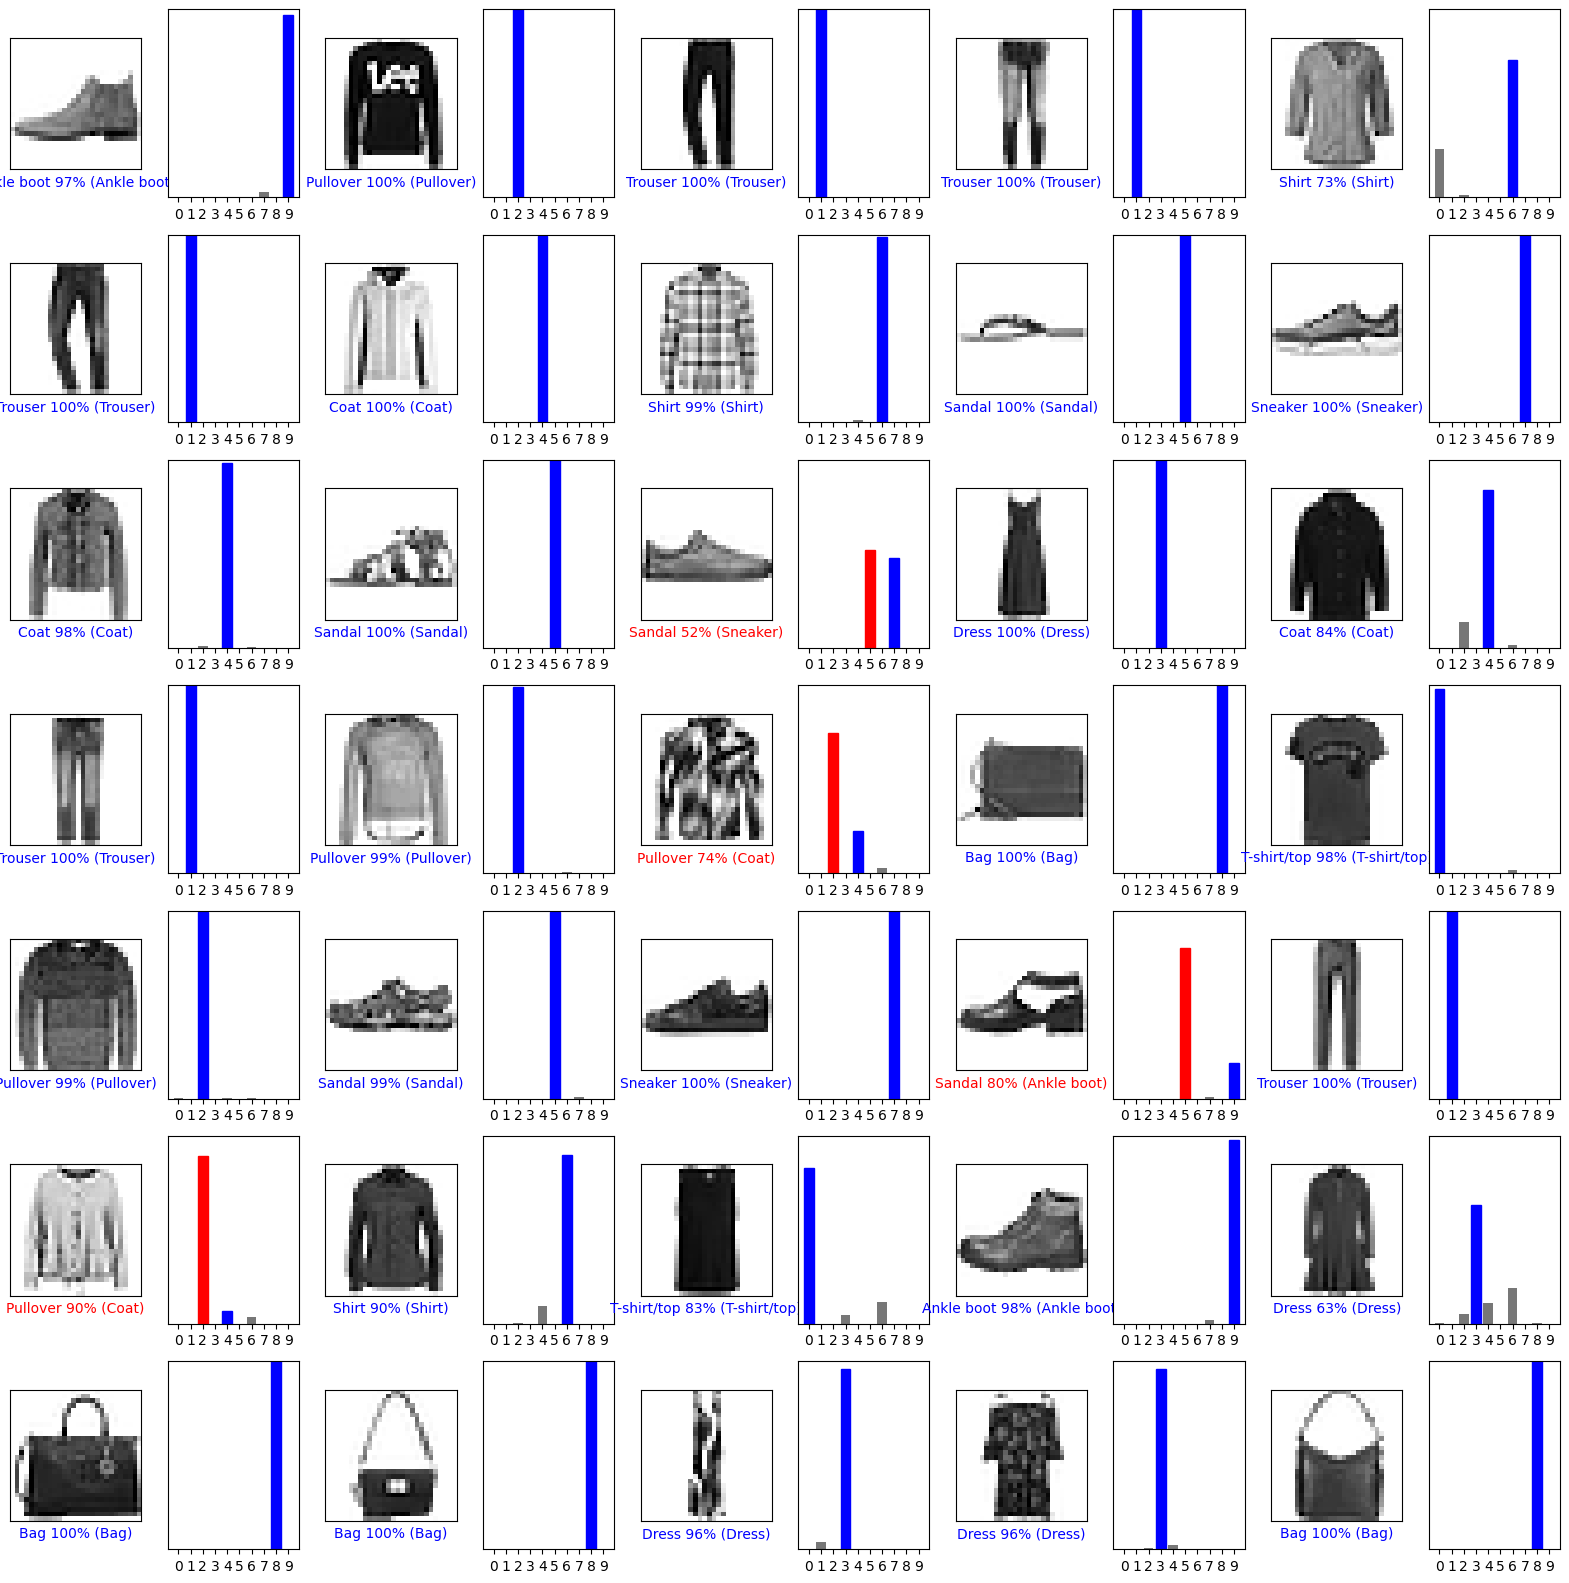

In [66]:
n_rows = 7
n_cols = 5
n_img = n_rows * n_cols

plt.figure(figsize=(20,20))

for i in range(n_img):
    # plt.figure(figsize=(15,7))
    plt.subplot(n_rows, n_cols*2, 2*i + 1)
    plot_image(i, y_pred[i], y_test, X_test)
    plt.subplot(n_rows, n_cols*2, 2*i + 2)
    plot_value_array(i, y_pred[i], y_test)

Evalúa tu modelo con una matriz de confusión e interprétala.

<Axes: >

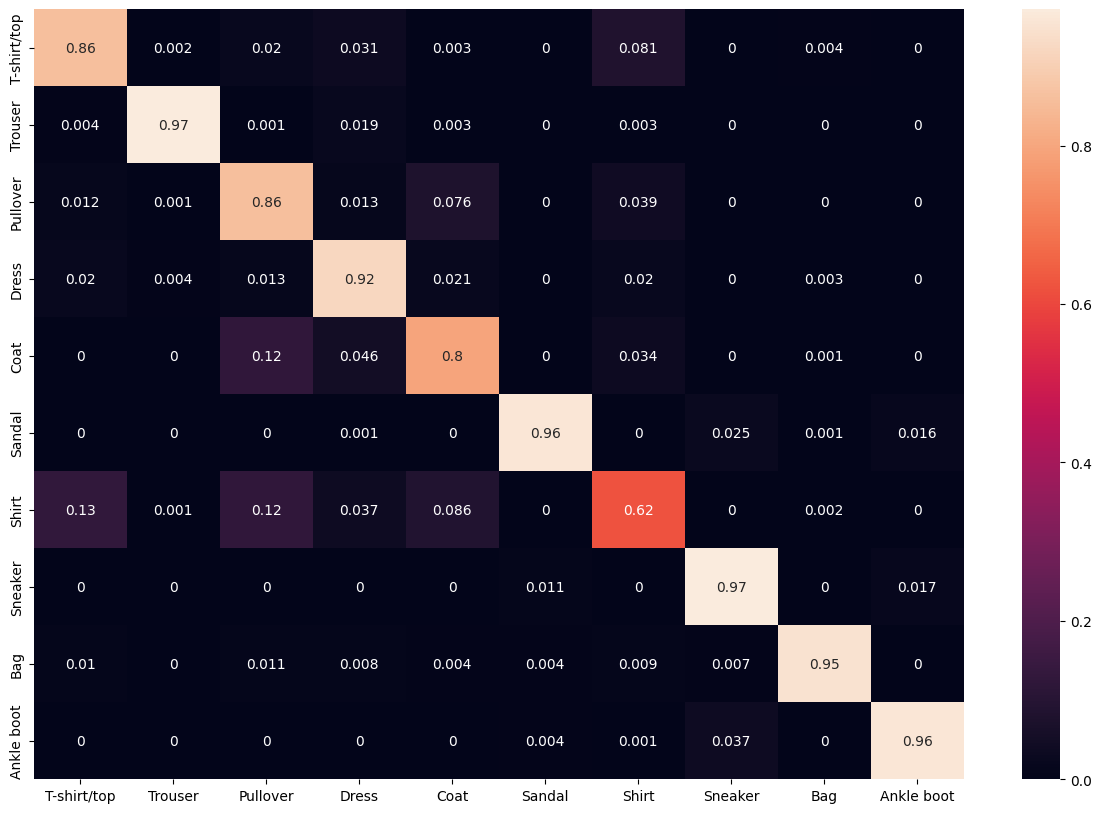

In [43]:
from sklearn.metrics import confusion_matrix

c_mat = confusion_matrix(y_test, y_pred_labels, normalize='true')
#c_mat = confusion_matrix(y_test, y_pred_labels)

plt.figure(figsize=(15,10))
sns.heatmap(c_mat, annot=True, xticklabels=class_names, yticklabels=class_names)

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_labels))

              precision    recall  f1-score   support

           0       0.83      0.86      0.85      1000
           1       0.99      0.97      0.98      1000
           2       0.75      0.86      0.80      1000
           3       0.86      0.92      0.89      1000
           4       0.80      0.80      0.80      1000
           5       0.98      0.96      0.97      1000
           6       0.77      0.62      0.69      1000
           7       0.93      0.97      0.95      1000
           8       0.99      0.95      0.97      1000
           9       0.97      0.96      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.88     10000
weighted avg       0.89      0.89      0.88     10000



Finalmente, usamos el modelo entrenado para hacer una prediccion sobre una única imagen.

In [45]:
class_names[np.argmax(model_2.predict(X_test[112:113]))]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


'Sneaker'